In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import os

from scipy.optimize import bisect, minimize
from scipy.integrate import odeint, simpson,quad

import scienceplots

plt.style.use('science')

import sys
sys.path.insert(1, '../detectability')

import resonance
from resonance import System, Filter, phase_diff_t_shift, jultosec,solve_ode,extra_flux_box, System, t_shift, t_shift_tanh

from pycbc.psd.read import from_txt

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
figures_path = 'figures/0_basis'
os.makedirs(figures_path, exist_ok=True)

In [3]:
#check functions for default parameters

m1 = 1.4 # M_sun
m2 = 1.4 # M_sun

f_low, f_high, tlen, srate, dL, approximant, detector = [15, 1024, 512, int(4*4096), 100, 'IMRPhenomD', 'aLIGO/AplusDesign']

binary = System(m1, m2)

filt = Filter(f_low, f_high, tlen, srate, dL, approximant, detector) #f_low, f_high, tlen, srate, dL, approximant, detector

Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 8192.000000 Hz, available 5000.000000 Hz)
/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [4]:
h = filt.template(m1, m2, distance=100)

dt = -1e-3
dtn=dt
fres=100

dt_arr = t_shift(dt,fres,filt.freqs)
dPsi = phase_diff_t_shift(dt,fres,filt.freqs)

h2 = h*np.exp(-1.j*dPsi)

#filt.snr(h, h2)

In [5]:
#dt = -1e-5
print(dt)

dF0 = binary.dF(dt, fres) 
print(dF0)

flux_frac1 = -binary.flux_frac_sharp_fres(dt, fres) 
print(flux_frac1)

dF = flux_frac1 * binary.flux(fres)
print(dF)

dE = binary.dE(dt, fres)/jultosec*1e7 #erg
print(dE)

-0.001
9.209546557759964e-11
0.017067781049638246
9.052360033545666e-11
1.9243432753612027e+48


In [6]:
#dPsi, dt, t,Psi,t_R,Psi_R = solve_ode(extra_flux=extra_flux_box(fres, 1, dF), f_low=f_low, tlen=tlen, srate=srate)

plt.figure()

plt.plot(filt.freqs, t, label='t. No resonance')
plt.plot(filt.freqs, t_R, label='t. Resonance')

plt.xlabel('Frequnecies [Hz]')
plt.ylabel('Time [s]')

plt.legend()
#plt.xlim((fres-2),(fres+2))
plt.show()


In [7]:
binary.merger_time(fres)

np.float64(-2.1596221619810283)

plt.figure()

plt.plot(t, filt.freqs, label='f. No resonance')
plt.plot(t_R, filt.freqs, label='f. Resonance')

plt.ylabel('Frequnecies [Hz]')
plt.xlabel('Time [s]')

plt.legend()
#plt.xlim(binary.merger_time(fres-20),binary.merger_time(fres+20))
plt.show()

plt.figure()

plt.plot(filt.freqs,binary.merger_time(filt.freqs),label='Analytical')
plt.plot(filt.freqs,t,label='Numerical. No resonance')
plt.plot(filt.freqs,t_R,label='Numerical. Resonance')

plt.xlim(f_low, 200)
plt.ylim(-100,0)

plt.show()


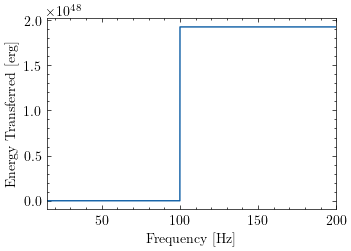

In [8]:
plt.figure(figsize=(3.5, 2.5), constrained_layout=True)


plt.plot(filt.freqs,np.where(filt.freqs>fres,dE,0))
plt.xlim(f_low, 200)

plt.ylabel('Energy Transferred [erg]')
plt.xlabel('Frequency [Hz]')

#plt.title('Energy Transferred')

plt.savefig(os.path.join(figures_path, f"E.png"), dpi=300)

plt.show()

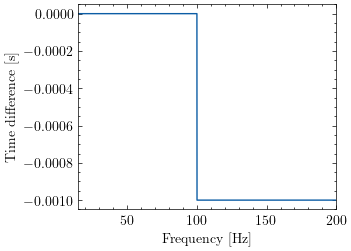

In [9]:
plt.figure(figsize=(3.5, 2.5), constrained_layout=True)

plt.plot(filt.freqs,dt_arr)
plt.xlim(f_low, 200)

plt.ylabel('Time difference [s]')
plt.xlabel('Frequency [Hz]')

#plt.title('Advance in time to merger')
plt.savefig(os.path.join(figures_path, f"dt.png"), dpi=300)

plt.show()

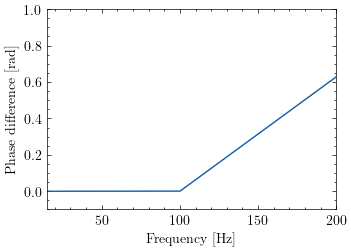

In [10]:
plt.figure(figsize=(3.5, 2.5), constrained_layout=True)

plt.plot(filt.freqs,-dPsi)
plt.xlim(f_low, 200)

plt.ylabel('Phase difference [rad]')
plt.xlabel('Frequency [Hz]')
plt.ylim(-0.1,1)

plt.savefig(os.path.join(figures_path, f"dpsi.png"), dpi=300)

plt.show()

#plt.title('Phase difference')
